# 🏥 Heart Failure Risk Prediction  

---

## 🧐 Context  

**Heart failure** is a severe chronic condition that impairs the heart’s ability to pump blood effectively. It can lead to life-threatening complications if not detected early.  

With the advancement of **medical data analysis** and **artificial intelligence**, we can now develop predictive models to assess heart failure risk and assist doctors in making more informed decisions.  

---

## 🎯 Project Objectives  

📌 **Our goal?** Develop a **Machine Learning model** capable of **predicting the risk of death** due to heart failure based on clinical data.  

📌 **Why?**  
🔹 Improve **patient care** and early risk detection.  
🔹 Identify the **most influential medical factors**.  
🔹 Provide a **clear explanation** of model predictions using **SHAP**.  
🔹 Design an **intuitive interface** for seamless clinical use.  



--
--

---

## 📊 Dataset Source  

📂 **Dataset Name**: *Heart Failure Clinical Records*  
📍 **Source**: UCI Machine Learning Repository  
🔗 **Link**: [UCI Heart Failure Dataset](https://archive.ics.uci.edu/dataset/519/heart%2Bfailure%2Bclinical%2Brecords)  

> 💡 This dataset contains **clinical data** on patients with heart failure, including biological measurements, medical history, and follow-up information. It serves as the foundation for training and testing our predictive models.  

---





## 🤖 Machine Learning Methodology  

📌 **1. Data Collection & Preprocessing**  
✔️ Load the dataset and explore its structure.  
✔️ Handle missing values and detect outliers.  
✔️ Optimize memory usage to improve performance.  
✔️ Perform feature selection and engineering if necessary.  

📌 **2. Handling Class Imbalance**  
✔️ Analyze the dataset distribution (68% survived, 32% deceased).  
✔️ Apply class balancing techniques such as **SMOTE, undersampling, or class-weighting**.  

📌 **3. Model Selection & Training**  
✔️ Choose at least three models for evaluation:  
   - Random Forest  
   - XGBoost  
   - LightGBM  
   - Logistic Regression  
✔️ Split the dataset into **training** and **test** sets.  
✔️ Train models using **cross-validation** for robustness.  

📌 **4. Model Evaluation**  
✔️ Assess performance using the following metrics:  
   - **ROC-AUC Score**  
   - **Accuracy**  
   - **Precision, Recall & F1-score**  
✔️ Compare model results and select the best-performing one.  

📌 **5. Model Explainability with SHAP**  
✔️ Implement **SHAP (SHapley Additive exPlanations)** to interpret model predictions.  
✔️ Generate **SHAP summary plots** to visualize feature importance.  

📌 **6. Deployment & User Interface**  
✔️ Develop an interactive **Flask** web application for real-time predictions.  
✔️ Allow physicians to input patient data and visualize results.  

---


****REQUIREMENTS INSTALLATION****

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.feature_selection import VarianceThreshold

# 1. Read Dataset

In [3]:
# Chargement du fichier
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [4]:
#Taille des données
data.shape

total = data.shape[0]
print("total of pacients %s"%(total))
print(f"The dataset has {data.shape[1]} features from {data.shape[0]} patients")

total of pacients 299
The dataset has 13 features from 299 patients


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


---

## 📌 **Description des Colonnes du Dataset**

| Nom de la colonne              | Description claire                                       | Type            | Unité                | Remarque                             |
|--------------------------------|----------------------------------------------------------|-----------------|----------------------|--------------------------------------|
| **anaemia**                    | Diminution des globules rouges ou de l'hémoglobine       | Booléen         | 0 (Non), 1 (Oui)    | Indicateur médical (anémie)          |
| **creatinine_phosphokinase**   | Niveau de l'enzyme CPK dans le sang                      | Quantitatif     | mcg/L                | Marqueur de lésion musculaire        |
| **diabetes**                   | Présence ou absence du diabète                           | Booléen         | 0 (Non), 1 (Oui)     | Facteur de risque cardiovasculaire   |
| **ejection_fraction**          | Fraction de sang éjectée du ventricule gauche            | Quantitatif     | Pourcentage (%)      | Indicateur clé de la fonction cardiaque |
| **high_blood_pressure**        | Hypertension artérielle                                  | Booléen         | 0=Non, 1=Oui         | Facteur de risque cardiovasculaire   |
| **platelets**                  | Nombre de plaquettes sanguines                           | Quantitatif     | kiloplaquettes/mL    | Important pour la coagulation        |
| **serum_creatinine**           | Concentration de créatinine sérique                      | Quantitatif     | mg/dL                | Indicateur de la fonction rénale     |
| **serum_sodium**               | Concentration de sodium dans le sang                     | Quantitatif     | mEq/L                | Régulateur nerveux et musculaire     |
| **sex**                        | Genre du patient                                         | Booléen         | 0=Femme, 1=Homme     | Caractéristique démographique        |
| **smoking**                    | Antécédent ou tabagisme actif                            | Booléen         | 0=Non, 1=Oui         | Facteur de risque cardiovasculaire   |
| **time**                       | Durée de suivi du patient                                | Quantitatif     | Jours                 | Durée de suivi du patient            |
| **DEATH_EVENT** (cible)        | Décès dû à une insuffisance cardiaque                    | Booléen         | 0=Survie, 1=Décès    | Variable cible à prédire             |

---

In [7]:
# Informations sur les types de données
print("Informations sur les types de données : \n")
data.info()

Informations sur les types de données : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10

**Optimizing Memory Usage**

In [8]:
# Optimisation mémoire avant Data Processing
def optimize_memory(df):
   
    mem_avant = df.memory_usage(deep=True).sum() / 1024**2
    print(f"\nMémoire initiale : {mem_avant:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        # Optimisation des colonnes numériques
        if col_type in ['int64', 'int32']:
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif col_type in ['float64', 'float32']:
            df[col] = pd.to_numeric(df[col], downcast='float')

        # Optimisation des colonnes catégorielles 
        elif col_type == 'object':
            num_uniques = df[col].nunique()
            num_total = len(df[col])
            if num_uniques / num_total < 0.5:  # Si peu de valeurs uniques, on convertit en category
                df[col] = df[col].astype('category')

    mem_apres = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Mémoire après optimisation : {mem_apres:.2f} MB")
    print(f"Réduction de mémoire : {100 * (mem_avant - mem_apres) / mem_avant:.2f}%\n")

    return df


data = optimize_memory(data)



Mémoire initiale : 0.03 MB
Mémoire après optimisation : 0.01 MB
Réduction de mémoire : 71.81%



# Preprocessing


### **Missing Value**

In [8]:
# Valeurs manquantes
print("\nValeurs manquantes dans le dataset :\n")
print(data.isnull().sum())


Valeurs manquantes dans le dataset :

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64




From dataset description, we can see that:

 * The shape of the dataset is (299, 13).
 * There are **no missing values**.
 * The data type of **age is float**. We'll convert it to integer.



In [9]:
data["age"] = data["age"].astype(int)

# 2. Exploratory Data Analysis

In [9]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


### 📌 Analyse des Variables du Dataset

D'après la description du dataset, nous pouvons observer que :

- **anaemia, diabetes, high_blood_pressure, sex, smoking et DEATH_EVENT** sont des variables qualitatives.  

- **Les autres variables sont quantitatives.**  

- **L'âge des patients est réparti entre 40 et 95 ans.**


**Visualisations**

Distribution des Variables Numériques

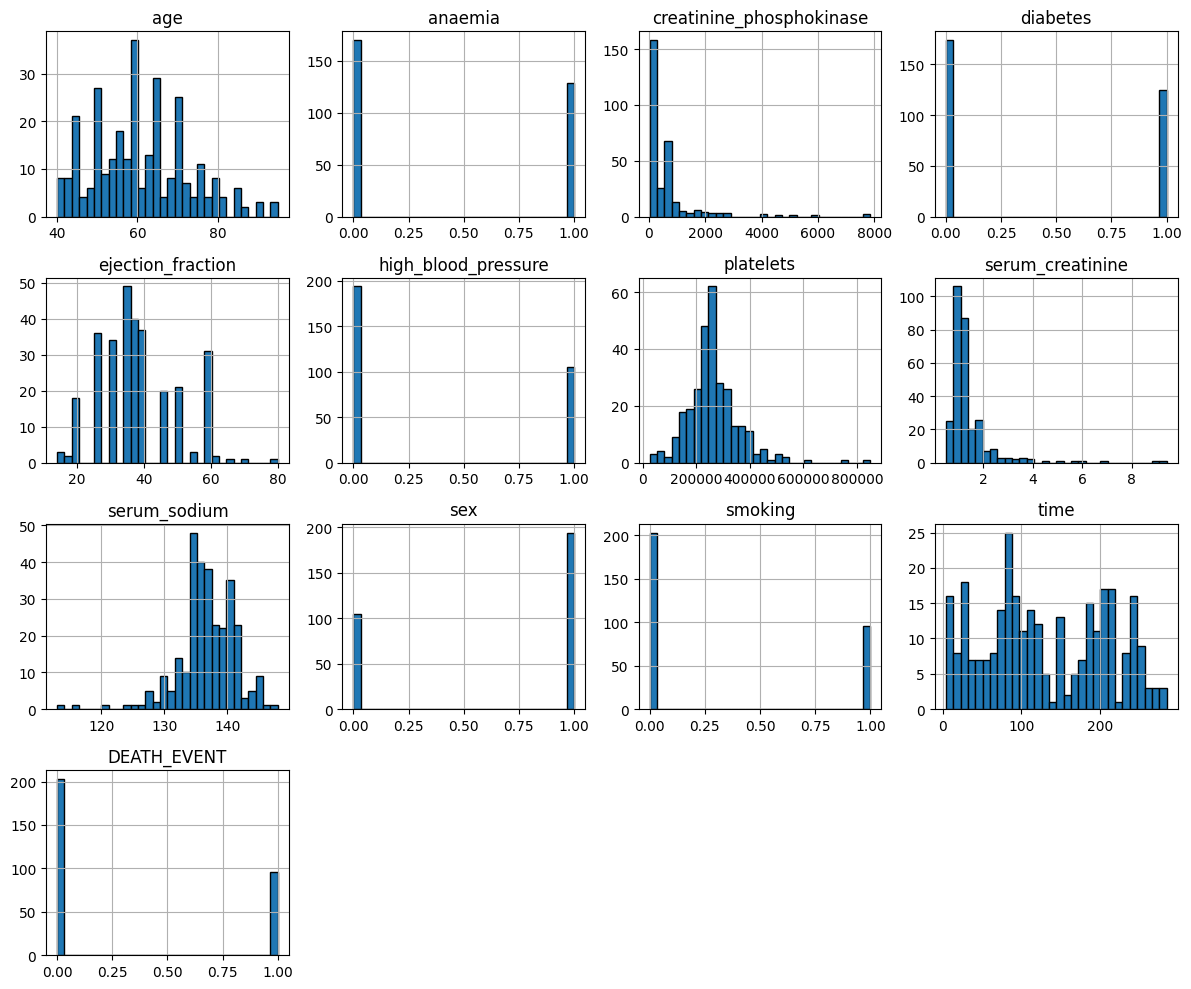

In [10]:
# Tracer des histogrammes pour toutes les colonnes numériques
data.hist(bins=30, figsize=(12, 10), edgecolor='black')

# Afficher les graphiques
plt.tight_layout()
plt.show()

Matrice de corrélation

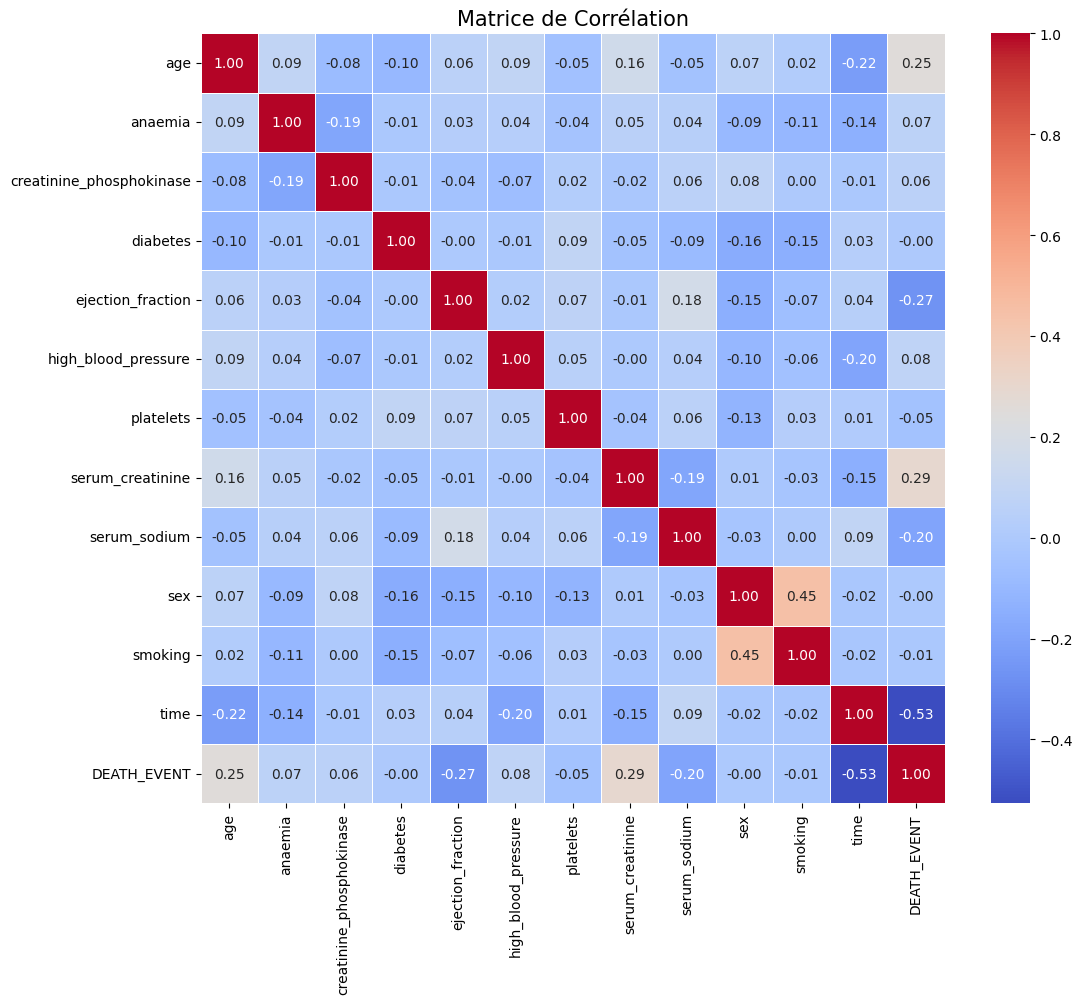

In [11]:
# Calcul de la matrice de corrélation
corr = data.corr()

# Tracer la heatmap avec les annotations des valeurs de corrélation
plt.figure(figsize=(12, 10))  # Ajuster la taille de la figure selon le nombre de colonnes
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)

# Ajouter un titre
plt.title('Matrice de Corrélation', fontsize=15)

# Afficher la heatmap
plt.show()

Boxplots par Feature

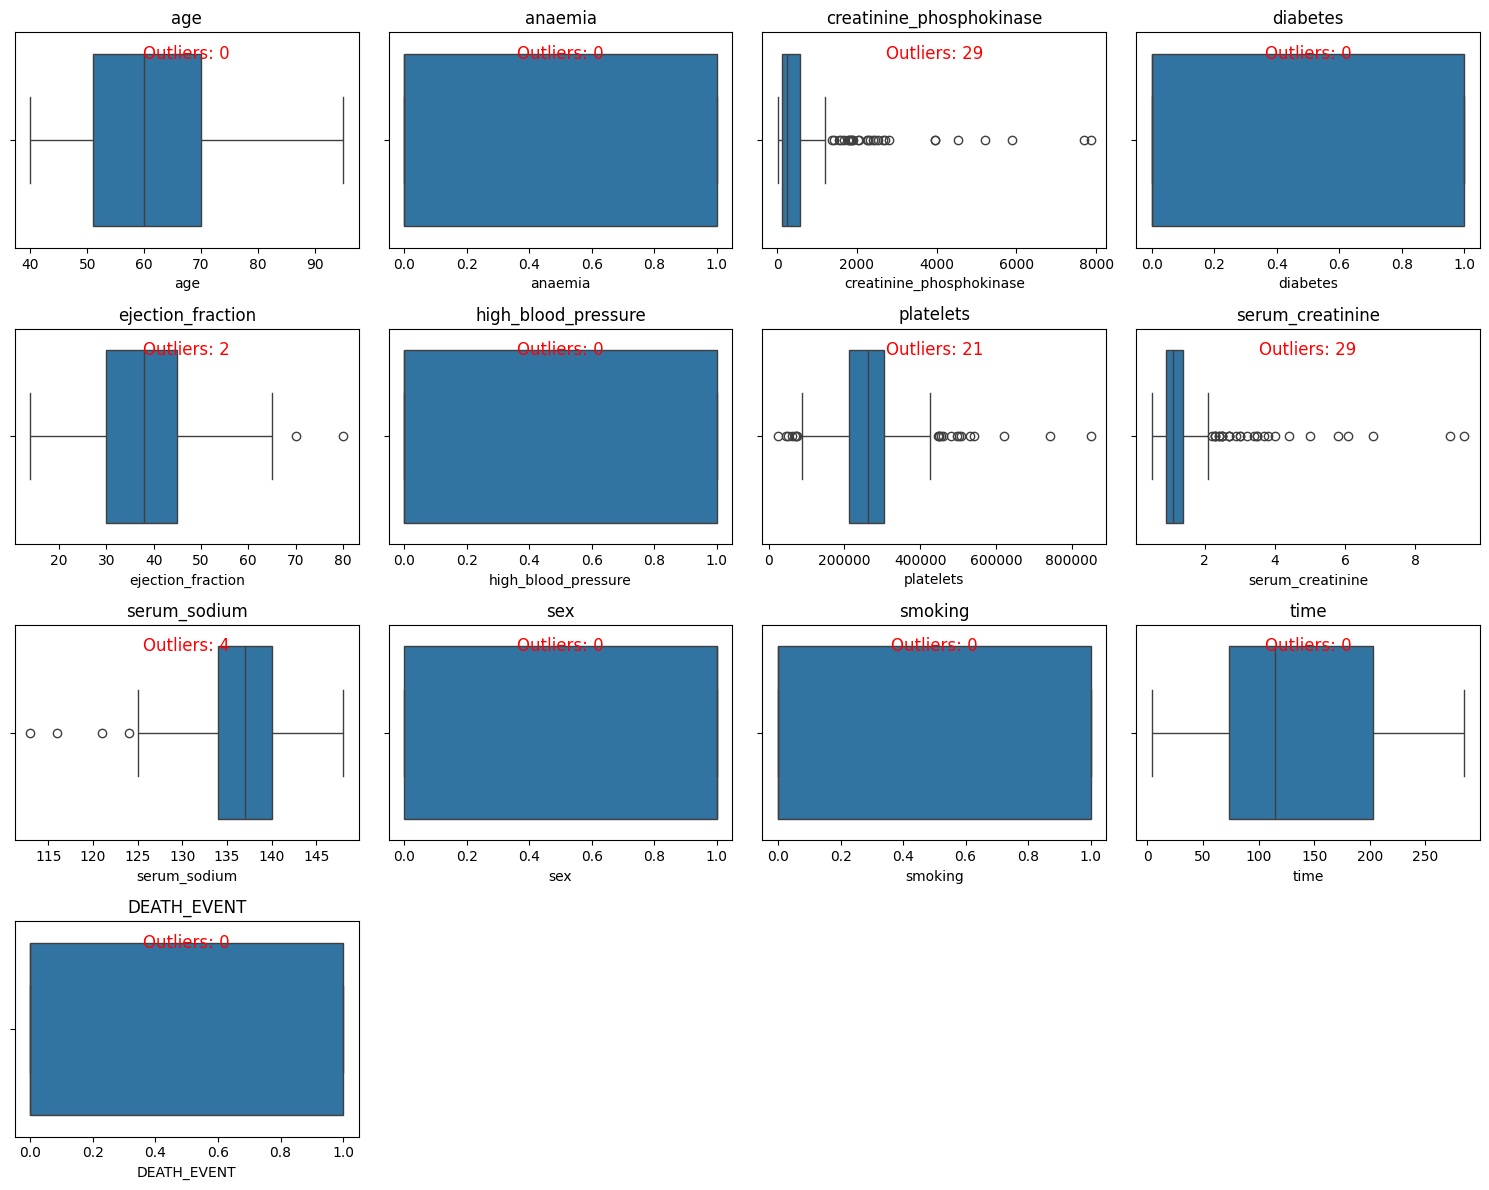

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Définir la taille de la figure
plt.figure(figsize=(15, 12))

# Calculer et afficher le nombre de valeurs aberrantes pour chaque variable
for i, col in enumerate(data.select_dtypes(include=['number']).columns):
    plt.subplot(4, 4, i + 1)  # Ajuste selon le nombre de colonnes
    sns.boxplot(x=data[col])
    plt.title(col)

    # Calcul des valeurs aberrantes
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Compter les valeurs aberrantes
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Afficher le nombre de valeurs aberrantes sur le graphique
    plt.text(0.5, 0.9, f'Outliers: {num_outliers}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.tight_layout()
plt.show()


**Prétraitement de données**

Prétraitement les valeurs aberrantes par la méthode de Médiane

In [14]:
import pandas as pd

# Créer une copie de la base de données d'origine pour éviter de modifier l'original
datanew = data.copy()

# Parcourir chaque colonne numérique
for col in datanew.select_dtypes(include=['number']).columns:
    # Calcul des valeurs aberrantes
    Q1 = datanew[col].quantile(0.25)
    Q3 = datanew[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Calcul de la médiane de la colonne
    median = datanew[col].median()

    # Remplacer les valeurs aberrantes par la médiane
    datanew[col] = datanew[col].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

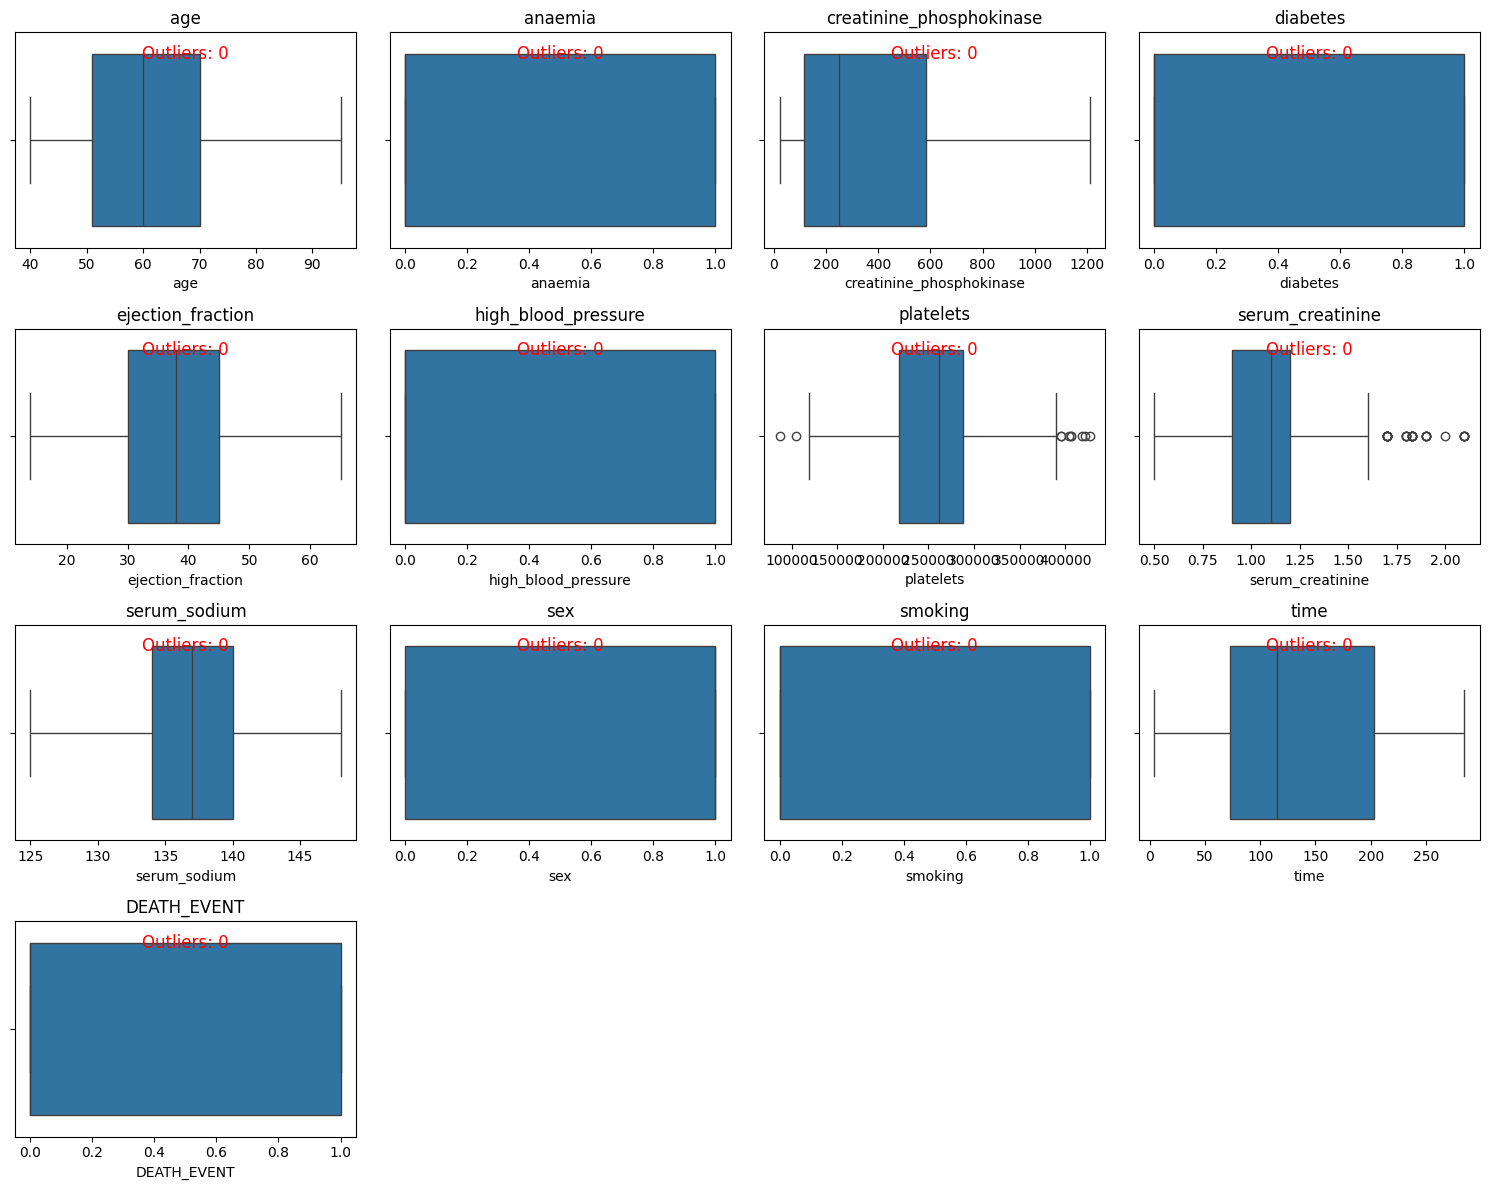

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Définir la taille de la figure
plt.figure(figsize=(15, 12))

# Calculer et afficher le nombre de valeurs aberrantes pour chaque variable
for i, col in enumerate(datanew.select_dtypes(include=['number']).columns):
    plt.subplot(4, 4, i + 1)  # Ajuste selon le nombre de colonnes
    sns.boxplot(x=datanew[col])
    plt.title(col)

    # Calcul des valeurs aberrantes
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Compter les valeurs aberrantes
    outliers = datanew[(datanew[col] < lower_bound) | (datanew[col] > upper_bound)]
    num_outliers = outliers.shape[0]

    # Afficher le nombre de valeurs aberrantes sur le graphique
    plt.text(0.5, 0.9, f'Outliers: {num_outliers}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.tight_layout()
plt.show()

Équilibrage du jeu de données (Data balancing)

Nombre de 0 (survie) : 203
Nombre de 1 (décès) : 96


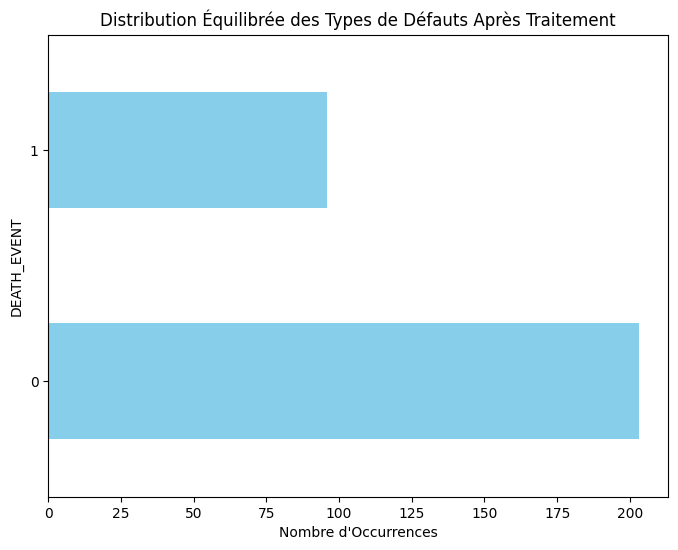

In [16]:
import matplotlib.pyplot as plt

# Extraire la colonne "DEATH_EVENT"
y = datanew["DEATH_EVENT"]

# Compter le nombre de 0 et 1
death_event_counts = y.value_counts()

# Afficher les résultats
print(f"Nombre de 0 (survie) : {death_event_counts[0]}")
print(f"Nombre de 1 (décès) : {death_event_counts[1]}")

# Tracer la distribution
plt.figure(figsize=(8, 6))
y.value_counts().plot(kind='barh', color='skyblue')
plt.title("Distribution Équilibrée des Types de Défauts Après Traitement")
plt.xlabel("Nombre d'Occurrences")
plt.ylabel("DEATH_EVENT")
plt.show()


Resampling par la méthode oversampling avec SMOTE pour atteindre 203 pour chaque classe dans le target

Nombre de 0 (survie) après rééchantillonnage : 203
Nombre de 1 (décès) après rééchantillonnage : 203


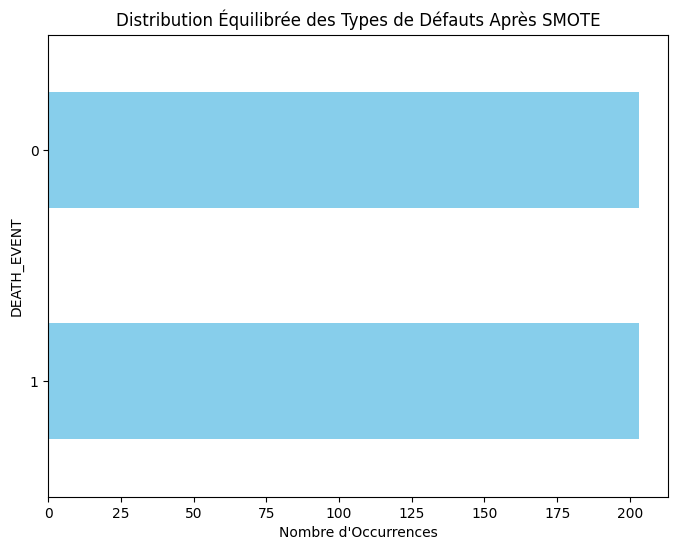

In [17]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# Séparer les variables indépendantes (features) et la variable cible (DEATH_EVENT)
X = datanew.drop(columns=["DEATH_EVENT"])
y = datanew["DEATH_EVENT"]

# Appliquer SMOTE pour réaliser un oversampling et équilibrer les classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Afficher la nouvelle distribution des classes après l'oversampling
print(f"Nombre de 0 (survie) après rééchantillonnage : {y_resampled.value_counts()[0]}")
print(f"Nombre de 1 (décès) après rééchantillonnage : {y_resampled.value_counts()[1]}")

# Créer un DataFrame avec les données rééchantillonnées
datanew_balanced = pd.DataFrame(X_resampled, columns=X.columns)
datanew_balanced["DEATH_EVENT"] = y_resampled

# Vérifier la distribution des données équilibrées
plt.figure(figsize=(8, 6))
datanew_balanced["DEATH_EVENT"].value_counts().plot(kind='barh', color='skyblue')
plt.title("Distribution Équilibrée des Types de Défauts Après SMOTE")
plt.xlabel("Nombre d'Occurrences")
plt.ylabel("DEATH_EVENT")
plt.show()


**Séparation des features et de la target pour la suite du traitement**

In [18]:
X = datanew_balanced.drop('DEATH_EVENT', axis=1)
y_final = datanew_balanced['DEATH_EVENT']

**Normalisation des données**

In [19]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Initialiser le scaler
scaler = StandardScaler()

# Appliquer le scaling sur les données équilibrées
data_scaled = scaler.fit_transform(X)

# Convertir le tableau NumPy en DataFrame
X_final = pd.DataFrame(data_scaled, columns=X.columns)

# Afficher les premières lignes du DataFrame mis à l'échelle
X_final.head(80)
X_final.shape

(406, 12)

**Séparation du dataset
en un jeu d'entraînement et un jeu de test**

In [20]:
# Séparation des données (validation simple). On peut demander la validation croisée)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X_final, y_final, test_size=0.2, random_state=0)
Y_train.shape

(324,)

**Implèmentation des modèles de ML et DL**

XGBoost Classifier **el houssine kamili**

XGBoost Classifier:
Accuracy: 0.9268
Precision: 0.9362
Recall: 0.9362
F1-Score: 0.9362
ROC-AUC: 0.9441


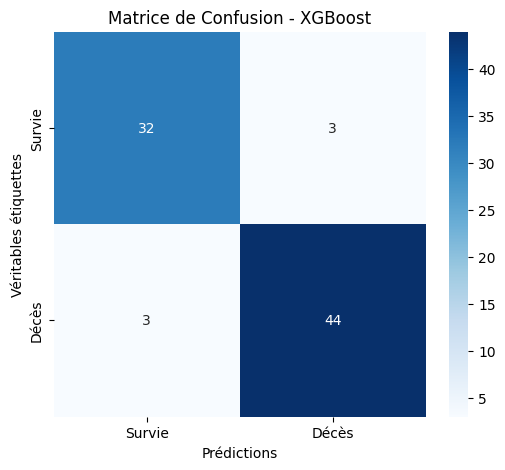

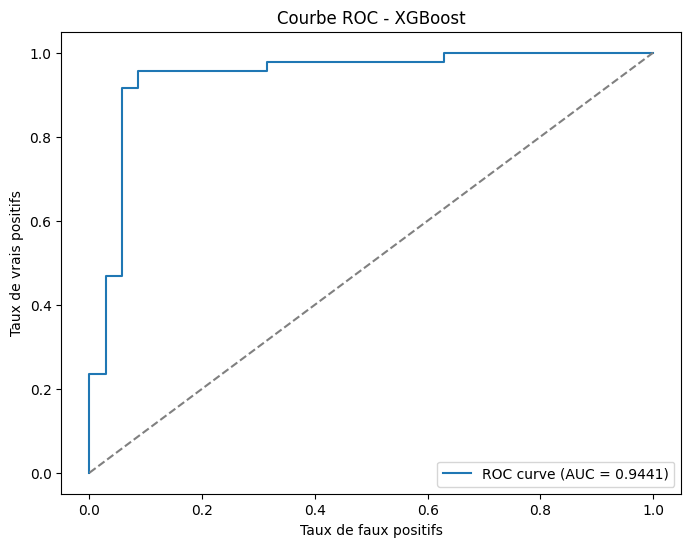

In [21]:
# XGBoost Classifier
import xgboost as xgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, Y_train)

# Prédictions
Y_pred_xgb = xgb_model.predict(X_test)
Y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_xgb = accuracy_score(Y_test, Y_pred_xgb)
precision_xgb = precision_score(Y_test, Y_pred_xgb)
recall_xgb = recall_score(Y_test, Y_pred_xgb)
f1_xgb = f1_score(Y_test, Y_pred_xgb)
roc_auc_xgb = roc_auc_score(Y_test, Y_prob_xgb)

# Affichage des résultats
print("XGBoost Classifier:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")

# Matrice de confusion
cm_xgb = confusion_matrix(Y_test, Y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - XGBoost")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_xgb, tpr_xgb, _ = roc_curve(Y_test, Y_prob_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC curve (AUC = {roc_auc_xgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - XGBoost")
plt.legend(loc="lower right")
plt.show()

Logistic Regression 

Logistic Regression:
Accuracy: 0.8537
Precision: 0.8431
Recall: 0.9149
F1-Score: 0.8776
ROC-AUC: 0.8881


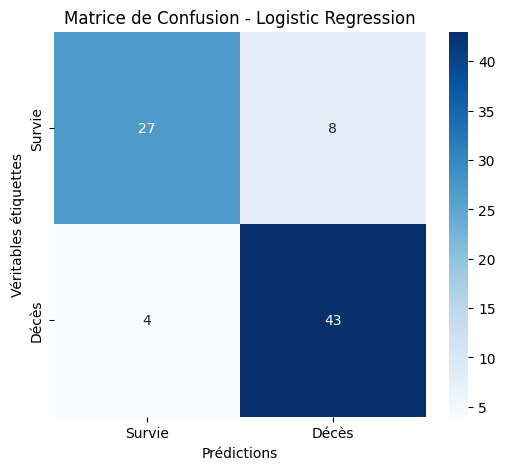

<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

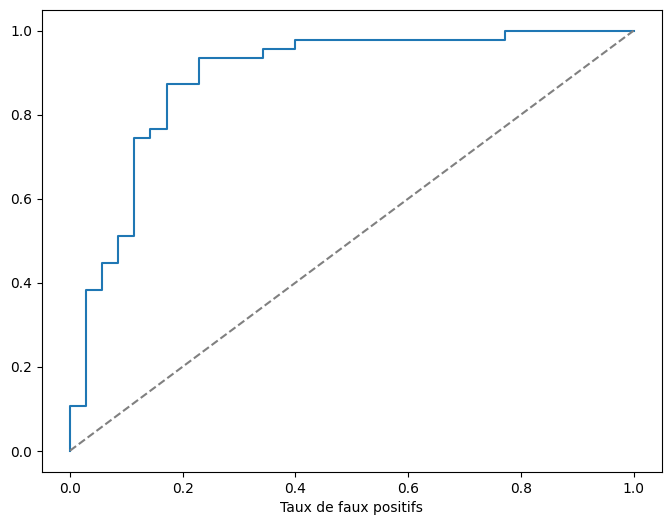

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
log_reg_model = LogisticRegression(random_state=42, max_iter=1000)
log_reg_model.fit(X_train, Y_train)

# Prédictions
Y_pred_log_reg = log_reg_model.predict(X_test)
Y_prob_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_log_reg = accuracy_score(Y_test, Y_pred_log_reg)
precision_log_reg = precision_score(Y_test, Y_pred_log_reg)
recall_log_reg = recall_score(Y_test, Y_pred_log_reg)
f1_log_reg = f1_score(Y_test, Y_pred_log_reg)
roc_auc_log_reg = roc_auc_score(Y_test, Y_prob_log_reg)

# Affichage des résultats
print("Logistic Regression:")
print(f"Accuracy: {accuracy_log_reg:.4f}")
print(f"Precision: {precision_log_reg:.4f}")
print(f"Recall: {recall_log_reg:.4f}")
print(f"F1-Score: {f1_log_reg:.4f}")
print(f"ROC-AUC: {roc_auc_log_reg:.4f}")

# Matrice de confusion
cm_log_reg = confusion_matrix(Y_test, Y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log_reg, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - Logistic Regression")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_log_reg, tpr_log_reg, _ = roc_curve(Y_test, Y_prob_log_reg)
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, label=f"ROC curve (AUC = {roc_auc_log_reg:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel

LightGBM Classifier **chahida**

In [ ]:
import lightgbm as lgb
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, roc_curve)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
import pandas as pd

# Charger un fichier CSV (remplace "mon_fichier.csv" par le bon nom de fichier)
df = pd.read_csv("C:\\Users\\princ\\Documents\\GitHub\\heart-failure-prediction\\notebooks\\heart_failure_clinical_records_dataset.csv")

# Vérifier le contenu
print(df.head())


# Supposons que df soit ton DataFrame et 'target' la colonne cible
X = df.drop(columns=['DEATH_EVENT'])
Y = df['DEATH_EVENT']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)


# Calcul du poids des classes pour gérer le déséquilibre
target_values = np.unique(Y_train)
class_weights = compute_class_weight('balanced', classes=target_values, y=Y_train)
class_weight_dict = {target_values[i]: class_weights[i] for i in range(len(target_values))}

# Entraînement du modèle avec ajustement du poids des classes
lgb_model = lgb.LGBMClassifier(random_state=42, scale_pos_weight=class_weight_dict[1])
lgb_model.fit(X_train, Y_train)

# Prédictions
Y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Optimisation du seuil de décision
fpr, tpr, thresholds = roc_curve(Y_test, Y_prob_lgb)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
Y_pred_lgb = (Y_prob_lgb >= optimal_threshold).astype(int)

# Évaluation des métriques
accuracy_lgb = accuracy_score(Y_test, Y_pred_lgb)
precision_lgb = precision_score(Y_test, Y_pred_lgb)
recall_lgb = recall_score(Y_test, Y_pred_lgb)
f1_lgb = f1_score(Y_test, Y_pred_lgb)
roc_auc_lgb = roc_auc_score(Y_test, Y_prob_lgb)

print("LightGBM Classifier:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")  # Très important en contexte médical
print(f"F1-Score: {f1_lgb:.4f}")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")
print(f"Seuil optimal: {optimal_threshold:.4f}")

# Matrice de confusion
cm_lgb = confusion_matrix(Y_test, Y_pred_lgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - LightGBM")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc_lgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - LightGBM")
plt.legend(loc="lower right")
plt.show()

# Explicabilité avec SHAP
explainer = shap.Explainer(lgb_model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)  # Affiche les features les plus influentes
'''# LightGBM Classifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, Y_train)

# Prédictions
Y_pred_lgb = lgb_model.predict(X_test)
Y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_lgb = accuracy_score(Y_test, Y_pred_lgb)
precision_lgb = precision_score(Y_test, Y_pred_lgb)
recall_lgb = recall_score(Y_test, Y_pred_lgb)
f1_lgb = f1_score(Y_test, Y_pred_lgb)
roc_auc_lgb = roc_auc_score(Y_test, Y_prob_lgb)

# Affichage des résultats
print("LightGBM Classifier:")
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"Precision: {precision_lgb:.4f}")
print(f"Recall: {recall_lgb:.4f}")
print(f"F1-Score: {f1_lgb:.4f}")
print(f"ROC-AUC: {roc_auc_lgb:.4f}")

# Matrice de confusion
cm_lgb = confusion_matrix(Y_test, Y_pred_lgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - LightGBM")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_lgb, tpr_lgb, _ = roc_curve(Y_test, Y_prob_lgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, label=f"ROC curve (AUC = {roc_auc_lgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - LightGBM")
plt.legend(loc="lower right")
plt.show()'''


ModuleNotFoundError: No module named 'shap'

Random Forest Classifier **el houssine kamili**

Random Forest Classifier:
Accuracy: 0.9024
Precision: 0.8980
Recall: 0.9362
F1-Score: 0.9167
ROC-AUC: 0.9778


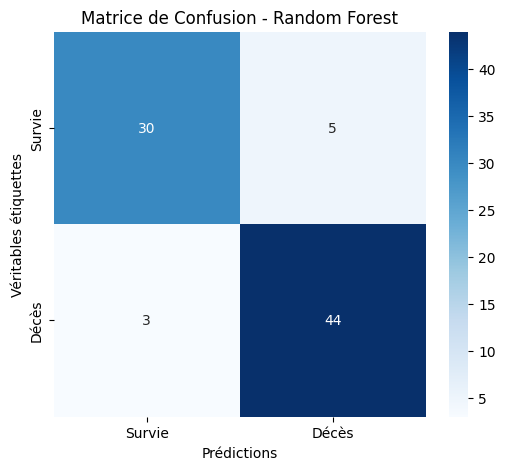

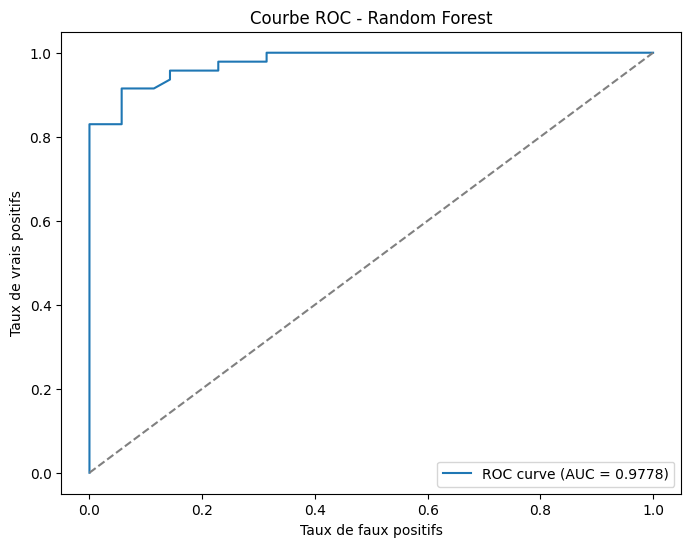

In [27]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Entraînement du modèle
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, Y_train)

# Prédictions
Y_pred_rf = rf_model.predict(X_test)
Y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Évaluation des métriques
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
precision_rf = precision_score(Y_test, Y_pred_rf)
recall_rf = recall_score(Y_test, Y_pred_rf)
f1_rf = f1_score(Y_test, Y_pred_rf)
roc_auc_rf = roc_auc_score(Y_test, Y_prob_rf)

# Affichage des résultats
print("Random Forest Classifier:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"ROC-AUC: {roc_auc_rf:.4f}")

# Matrice de confusion
cm_rf = confusion_matrix(Y_test, Y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["Survie", "Décès"], yticklabels=["Survie", "Décès"])
plt.title("Matrice de Confusion - Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Véritables étiquettes")
plt.show()

# Courbe ROC
fpr_rf, tpr_rf, _ = roc_curve(Y_test, Y_prob_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"ROC curve (AUC = {roc_auc_rf:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Random Forest")
plt.legend(loc="lower right")
plt.show()


Analysis of features to identify characteristics with the most significant impact on cardiac risk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif


df = pd.read_csv('heart_failure_clinical_records_dataset.csv')


X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)


feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Importance des Caractéristiques pour le Risque Cardiaque')
plt.tight_layout()
plt.show()

ARTIFICIAL NEURAL NETWORK FOR HEART FAILURE RISK ESTIMATION

Chargement des données...
Dimensions du dataset: (299, 13)

Entraînement du RNA...
Iteration 0, Erreur: 1.549549
Iteration 100, Erreur: 0.357790
Iteration 200, Erreur: 0.318369
Iteration 300, Erreur: 0.292566
Iteration 400, Erreur: 0.271522
Iteration 500, Erreur: 0.254442
Iteration 600, Erreur: 0.238684
Iteration 700, Erreur: 0.222139
Iteration 800, Erreur: 0.206181
Iteration 900, Erreur: 0.192950
Iteration 1000, Erreur: 0.183397
Iteration 1100, Erreur: 0.176834
Iteration 1200, Erreur: 0.172378
Iteration 1300, Erreur: 0.169394
Iteration 1400, Erreur: 0.167424


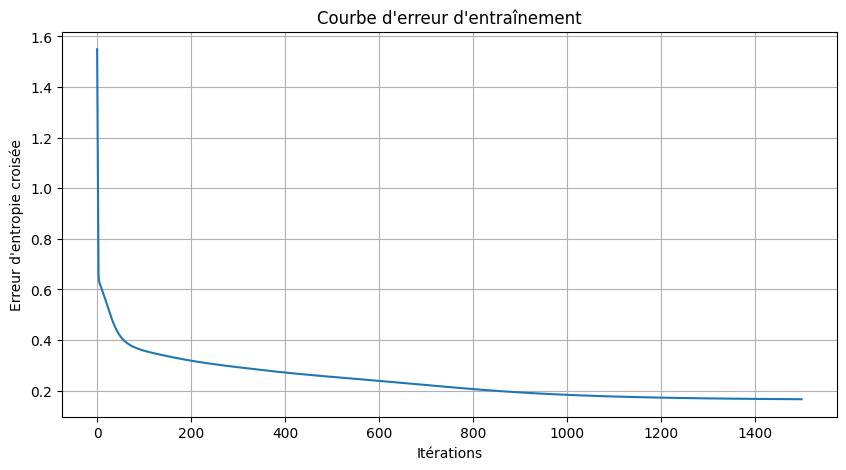


Métriques d'évaluation du RNA:
Accuracy: 0.8333
Precision: 0.8000
Recall: 0.6316
F1-Score: 0.7059
AUC-ROC: 0.8524


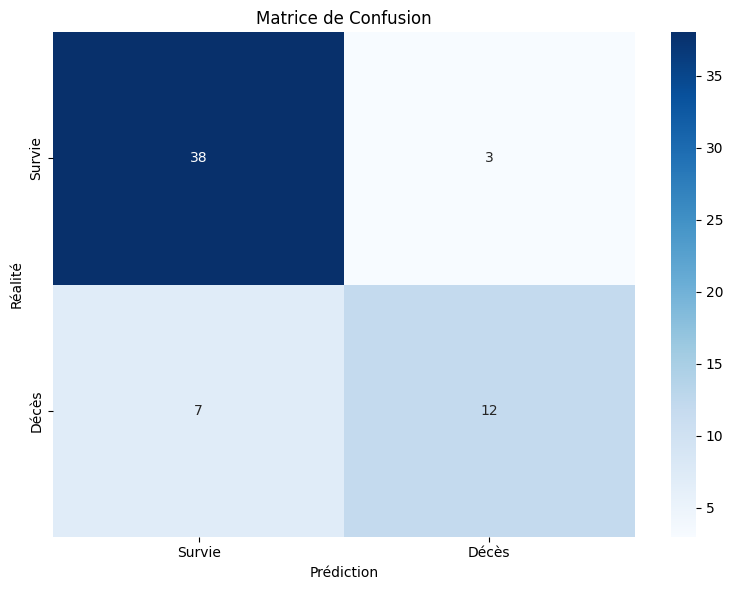

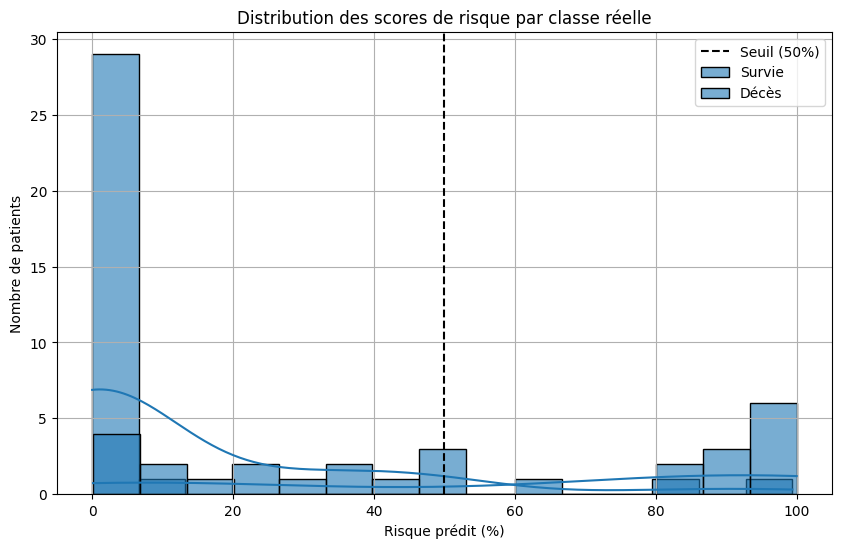

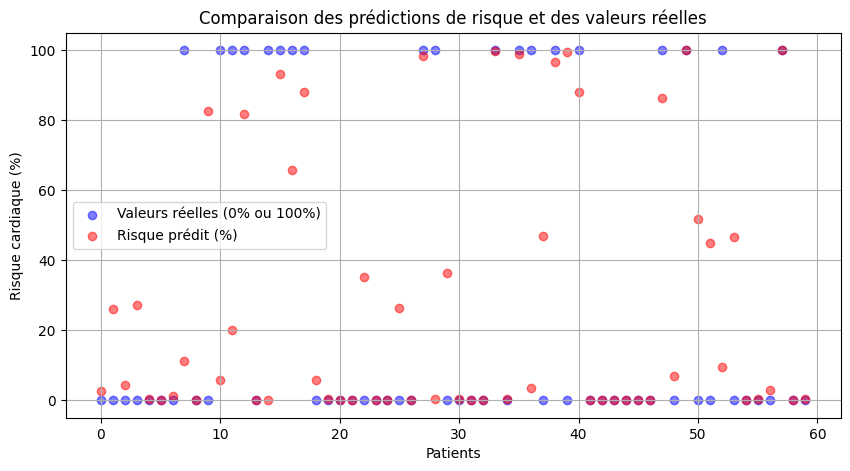


Exemple de prédiction pour un nouveau patient:
Risque cardiaque prédit: 2.62%
Classe prédite: Survie
Catégorie de risque: FAIBLE

Résumé des résultats:
                                     Modèle  Accuracy  Precision    Recall  \
0  Réseau de Neurones pour Risque Cardiaque  0.833333        0.8  0.631579   

   F1-Score   AUC-ROC  
0  0.705882  0.852375  


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from urllib.request import urlretrieve
import os


def get_data(url="https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"):
    if not os.path.exists('data'):
        os.makedirs('data')
    
    file_path = 'data/heart_failure_clinical_records_dataset.csv'
    
    if not os.path.exists(file_path):
        print(f"Téléchargement du dataset vers {file_path}...")
        urlretrieve(url, file_path)
        print("Téléchargement terminé!")
    
    return pd.read_csv(file_path)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)


def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

class CardiacRiskRNA:
    def __init__(self, x, y):
        self.input = x
        self.hidden_size = 50 
        self.weights1 = np.random.rand(self.input.shape[1], 10)
        self.weights2 = np.random.rand(10, 1)                 
        self.y = y
        self.output = np.zeros(y.shape)
        self.learning_rate = 0.01
        self.lambda_reg = 0.01

    def feedforward(self):
        self.layer1 = sigmoid(np.dot(self.input, self.weights1))
        self.output = sigmoid(np.dot(self.layer1, self.weights2))

    def backprop(self):
        
        d_loss = 2 * (self.y - self.output)
        d_output = d_loss * sigmoid_derivative(self.output)
        

        d_weights2 = np.dot(self.layer1.T, d_output)
        d_hidden = np.dot(d_output, self.weights2.T) * sigmoid_derivative(self.layer1)
        d_weights1 = np.dot(self.input.T, d_hidden)
        

        self.weights1 += self.learning_rate * d_weights1
        self.weights2 += self.learning_rate * d_weights2

    def train(self, X, y, epochs=1500):
        self.input = X
        self.y = y
        
        erreurs = []  
        
        for i in range(epochs):
            self.feedforward()
            self.backprop()
            
            erreur = binary_cross_entropy(self.y, self.output)
            erreurs.append(erreur)
            
            if i % 100 == 0:
                print(f"Iteration {i}, Erreur: {erreur:.6f}")
        
        return erreurs

    def predict_risk(self, X):
        """Prédit le risque cardiaque en pourcentage (0-100%)"""
        self.input = X
        self.feedforward()
        return self.output * 100
    
    def predict_class(self, X, threshold=0.5):
        """Prédit la classe binaire (0/1) en appliquant un seuil au risque"""
        self.input = X
        self.feedforward()
        return (self.output >= threshold).astype(int)


print("Chargement des données...")
df = get_data()
print(f"Dimensions du dataset: {df.shape}")


X = df.drop('DEATH_EVENT', axis=1).values
y = df['DEATH_EVENT'].values.reshape(-1, 1)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


print("\nEntraînement du RNA...")
nn = CardiacRiskRNA(X_train, y_train)
erreurs = nn.train(X_train, y_train, epochs=1500)


plt.figure(figsize=(10, 5))
plt.plot(erreurs)
plt.title('Courbe d\'erreur d\'entraînement')
plt.xlabel('Itérations')
plt.ylabel('Erreur d\'entropie croisée')
plt.grid(True)
plt.savefig('erreur_entrainement.png')
plt.show()


y_risk = nn.predict_risk(X_test)
y_pred = nn.predict_class(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_risk/100)

print("\nMétriques d'évaluation du RNA:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
           xticklabels=["Survie", "Décès"],
           yticklabels=["Survie", "Décès"])
plt.title('Matrice de Confusion')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.tight_layout()
plt.savefig('matrice_confusion.png')
plt.show()


plt.figure(figsize=(10, 6))
risk_class0 = y_risk[y_test.flatten() == 0]
risk_class1 = y_risk[y_test.flatten() == 1]

sns.histplot(risk_class0, color='green', alpha=0.6, label='Survie', kde=True, bins=15)
sns.histplot(risk_class1, color='red', alpha=0.6, label='Décès', kde=True, bins=15)

plt.axvline(x=50, color='black', linestyle='--', label='Seuil (50%)')
plt.title('Distribution des scores de risque par classe réelle')
plt.xlabel('Risque prédit (%)')
plt.ylabel('Nombre de patients')
plt.legend()
plt.grid(True)
plt.savefig('distribution_risque.png')
plt.show()

# Comparaison des prédictions avec la réalité
plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_test)), y_test.flatten() * 100, color='blue', alpha=0.5, label='Valeurs réelles (0% ou 100%)')
plt.scatter(range(len(y_test)), y_risk.flatten(), color='red', alpha=0.5, label='Risque prédit (%)')
plt.title('Comparaison des prédictions de risque et des valeurs réelles')
plt.xlabel('Patients')
plt.ylabel('Risque cardiaque (%)')
plt.legend()
plt.grid(True)
plt.savefig('predictions_vs_realite.png')
plt.show()

# Exemple de prédiction pour un nouveau patient
print("\nExemple de prédiction pour un nouveau patient:")
nouveau_patient = np.array([[65, 1, 300, 1, 25, 1, 200000, 1.5, 135, 1, 0, 100]])
nouveau_patient_norm = scaler.transform(nouveau_patient)
risque_predit = nn.predict_risk(nouveau_patient_norm)[0][0]
classe_predite = nn.predict_class(nouveau_patient_norm)[0][0]

print(f"Risque cardiaque prédit: {risque_predit:.2f}%")
print(f"Classe prédite: {'Décès' if classe_predite == 1 else 'Survie'}")

if risque_predit >= 75:
    categorie = "TRÈS ÉLEVÉ"
elif risque_predit >= 50:
    categorie = "ÉLEVÉ"
elif risque_predit >= 25:
    categorie = "MODÉRÉ"
else:
    categorie = "FAIBLE"

print(f"Catégorie de risque: {categorie}")

# Résumé des résultats pour comparaison
resultats = {
    'Modèle': ['Réseau de Neurones pour Risque Cardiaque'],
    'Accuracy': [accuracy],
    'Precision': [precision], 
    'Recall': [recall],
    'F1-Score': [f1],
    'AUC-ROC': [auc]
}

resultats_df = pd.DataFrame(resultats)
print("\nRésumé des résultats:")
print(resultats_df)

if not os.path.exists('results'):
    os.makedirs('results')
resultats_df.to_csv('results/resultats_rna.csv', index=False)

SHAP explainability of the ANN

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from urllib.request import urlretrieve
import os

# ============ Fonctions de base pour le modèle ============

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def get_data(url="https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"):
    if not os.path.exists('data'):
        os.makedirs('data')
    
    file_path = 'data/heart_failure_clinical_records_dataset.csv'
    
    if not os.path.exists(file_path):
        print(f"Téléchargement du dataset vers {file_path}...")
        urlretrieve(url, file_path)
        print("Téléchargement terminé!")
    
    return pd.read_csv(file_path)

# ============ Classe du modèle neuronal ============

class CardiacRiskRNA:
    def __init__(self, x, y):
        self.input = x
        self.weights1 = np.random.rand(self.input.shape[1], 10)
        self.weights2 = np.random.rand(10, 1)                 
        self.y = y
        self.output = np.zeros(y.shape)
        self.learning_rate = 0.01

    def feedforward(self):
        self.layer1 = sigmoid(np.dot(self.input, self.weights1))
        self.output = sigmoid(np.dot(self.layer1, self.weights2))

    def backprop(self):
        d_loss = 2 * (self.y - self.output)
        d_output = d_loss * self.output * (1 - self.output)
        
        d_weights2 = np.dot(self.layer1.T, d_output)
        d_hidden = np.dot(d_output, self.weights2.T) * self.layer1 * (1 - self.layer1)
        d_weights1 = np.dot(self.input.T, d_hidden)
        
        self.weights1 += self.learning_rate * d_weights1
        self.weights2 += self.learning_rate * d_weights2

    def train(self, X, y, epochs=1500):
        self.input = X
        self.y = y
        
        erreurs = []  
        
        for i in range(epochs):
            self.feedforward()
            self.backprop()
            
            erreur = binary_cross_entropy(self.y, self.output)
            erreurs.append(erreur)
            
            if i % 100 == 0:
                print(f"Iteration {i}, Erreur: {erreur:.6f}")
        
        return erreurs

    def predict_risk(self, X):
        """Prédit le risque cardiaque en pourcentage (0-100%)"""
        self.input = X
        self.feedforward()
        return self.output * 100

# ============ Classe SHAP simplifiée (sans visualisation) ============

class SimpleShapExplainer:
    def __init__(self, model, feature_names):
        """
        Crée un simple explainer SHAP pour le modèle cardio
        
        model: Un modèle CardiacRiskRNA entraîné
        feature_names: Liste des noms des caractéristiques
        """
        self.model = model
        self.feature_names = feature_names
        
    def calculate_contribution(self, X, background, samples=10):
        """
        Calcule une approximation simple des valeurs SHAP
        
        X: Entrée à expliquer (1 échantillon)
        background: Données d'arrière-plan pour définir la valeur de base
        samples: Nombre d'échantillons à utiliser pour l'approximation
        """
        # Valeur de base = prédiction moyenne sur les données d'arrière-plan
        self.model.input = background
        self.model.feedforward()
        base_value = np.mean(self.model.output)
        
        # Prédiction pour X
        x_flat = X.flatten()
        self.model.input = X
        self.model.feedforward()
        prediction = self.model.output[0, 0]
        
        # Calcul des contributions par une méthode simple
        contributions = []
        
        # Pour chaque caractéristique
        for i in range(len(self.feature_names)):
            # Créer des copies du background avec la valeur de X pour la caractéristique i
            modified_background = background.copy()
            modified_background[:, i] = x_flat[i]
            
            # Prédire sur ce background modifié
            self.model.input = modified_background
            self.model.feedforward()
            modified_preds = self.model.output
            
            # Contribution = différence moyenne des prédictions
            contribution = np.mean(modified_preds) - base_value
            contributions.append(contribution)
        
        # Normaliser les contributions pour qu'elles additionnent à (prediction - base_value)
        total_contrib = sum(contributions)
        scaling_factor = (prediction - base_value) / total_contrib if total_contrib != 0 else 0
        scaled_contribs = [c * scaling_factor for c in contributions]
        
        return {
            'base_value': float(base_value),
            'prediction': float(prediction),
            'contributions': list(zip(self.feature_names, scaled_contribs))
        }
        
    def explain(self, X, background):
        """Explique la prédiction pour X"""
        # Calculer les contributions
        result = self.calculate_contribution(X, background)
        
        # Trier les contributions par valeur absolue
        sorted_contribs = sorted(
            result['contributions'], 
            key=lambda x: abs(x[1]), 
            reverse=True
        )
        
        # Calculer la catégorie de risque
        risk = float(result['prediction']) * 100  # Convertir en pourcentage
        if risk >= 75:
            category = "TRÈS ÉLEVÉ"
        elif risk >= 50:
            category = "ÉLEVÉ"
        elif risk >= 25:
            category = "MODÉRÉ"
        else:
            category = "FAIBLE"
            
        # Caractéristiques qui augmentent le risque
        increasing = [f for f, v in sorted_contribs if v > 0]
        # Caractéristiques qui diminuent le risque
        decreasing = [f for f, v in sorted_contribs if v < 0]
        
        # Retourner les résultats
        return {
            'risk': risk,
            'category': category,
            'base_value': result['base_value'] * 100,  # en pourcentage
            'contributions': sorted_contribs,
            'top_increasing': increasing[:3] if len(increasing) >= 3 else increasing,
            'top_decreasing': decreasing[:3] if len(decreasing) >= 3 else decreasing
        }

# ============ Script principal ============

if __name__ == "__main__":
    print("Chargement et préparation des données...")
    df = get_data()
    
    # Préparer les données
    X = df.drop('DEATH_EVENT', axis=1).values
    y = df['DEATH_EVENT'].values.reshape(-1, 1)

    # Standardiser les caractéristiques
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Diviser en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    # Option 1: Entraîner un nouveau modèle (plus long)
    print("\nEntraînement d'un nouveau modèle RNA...")
    nn = CardiacRiskRNA(X_train, y_train)
    erreurs = nn.train(X_train, y_train, epochs=1000)  # Réduit à 1000 pour gagner du temps
    
    # Option 2: Utiliser un modèle préentraîné (décommenter si vous avez des poids sauvegardés)
    # nn = CardiacRiskRNA(X_train, y_train)
    # nn.weights1 = np.load('weights1.npy')
    # nn.weights2 = np.load('weights2.npy')
    
    # Définir les noms des caractéristiques
    feature_names = [
        'Age', 'Anaemia', 'Creatinine Phosphokinase', 'Diabetes', 
        'Ejection Fraction', 'High Blood Pressure', 'Platelets',
        'Serum Creatinine', 'Serum Sodium', 'Sex', 'Smoking', 'Time'
    ]
    
    # Créer l'explainer SHAP simplifié
    print("\nCréation de l'explainer SHAP...")
    explainer = SimpleShapExplainer(nn, feature_names)
    
    # Patient de test
    print("\nExplication pour un nouveau patient:")
    new_patient = np.array([[65, 1, 300, 1, 25, 1, 200000, 1.5, 135, 1, 0, 100]])
    new_patient_norm = scaler.transform(new_patient)
    
    # Générer l'explication
    explanation = explainer.explain(new_patient_norm, X_train[:50])
    
    # Afficher les résultats
    print("\n===== RÉSULTATS DE L'ANALYSE SHAP =====")
    print(f"Risque prédit: {explanation['risk']:.2f}%")
    print(f"Catégorie de risque: {explanation['category']}")
    print(f"Valeur de base: {explanation['base_value']:.2f}%")
    
    print("\nContributions des caractéristiques (triées par impact):")
    for feature, value in explanation['contributions']:
        direction = "augmente" if value > 0 else "diminue"
        print(f"  - {feature}: {abs(value*100):.2f}% ({direction} le risque)")
    
    print("\nPrincipales caractéristiques qui augmentent le risque:")
    for feature in explanation['top_increasing']:
        print(f"  - {feature}")
    
    print("\nPrincipales caractéristiques qui diminuent le risque:")
    for feature in explanation['top_decreasing']:
        print(f"  - {feature}")
        
    print("\n=================================")
    print("Cette explication peut maintenant être intégrée à l'interface web.")
    
    # Exemple de code pour l'intégration web (à adapter pour votre cas d'utilisation)
    def simulerPredictionRNA(features_list):
        """Fonction pour l'interface web"""
        # Normaliser les données
        features = np.array([features_list])
        features_norm = scaler.transform(features)
        
        # Prédire le risque
        return float(nn.predict_risk(features_norm)[0][0])
    
    def genererExplication(features_list, background_data=None):
        """Fonction pour l'explication dans l'interface web"""
        # Normaliser les données
        features = np.array([features_list])
        features_norm = scaler.transform(features)
        
        # Utiliser les données d'entraînement comme background par défaut
        if background_data is None:
            background_data = X_train[:50]
            
        # Générer l'explication
        return explainer.explain(features_norm, background_data)

Chargement et préparation des données...

Entraînement d'un nouveau modèle RNA...
Iteration 0, Erreur: 2.253075
Iteration 100, Erreur: 0.357430
Iteration 200, Erreur: 0.331235
Iteration 300, Erreur: 0.307979
Iteration 400, Erreur: 0.286636
Iteration 500, Erreur: 0.270936
Iteration 600, Erreur: 0.257141
Iteration 700, Erreur: 0.246935
Iteration 800, Erreur: 0.238659
Iteration 900, Erreur: 0.231686

Création de l'explainer SHAP...

Explication pour un nouveau patient:

===== RÉSULTATS DE L'ANALYSE SHAP =====
Risque prédit: 10.84%
Catégorie de risque: FAIBLE
Valeur de base: 30.34%

Contributions des caractéristiques (triées par impact):
  - Ejection Fraction: 11.38% (diminue le risque)
  - Time: 5.12% (diminue le risque)
  - Serum Creatinine: 3.72% (diminue le risque)
  - Age: 3.48% (diminue le risque)
  - Creatinine Phosphokinase: 2.84% (augmente le risque)
  - Smoking: 2.24% (augmente le risque)
  - Sex: 2.22% (augmente le risque)
  - High Blood Pressure: 2.06% (augmente le risque)
  - 